In [1]:
import pandas as pd
csv_path = r"..\..\data\massa_1.csv"
# --- Replace with your actual data file ---
df = pd.read_csv(csv_path)

# --- Replace with the name of your datetime column ---
time_col = "date"

# Try parsing timestamps safely
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# Drop unparseable (NaT) timestamps
n_invalid = df[time_col].isna().sum()
print(f"❗ Invalid timestamps dropped: {n_invalid}")

df = df.dropna(subset=[time_col]).sort_values(time_col)

# Set index for convenience
df = df.set_index(time_col)

# --- Check continuity ---
# Compute time difference between consecutive timestamps
diffs = df.index.to_series().diff()

# Count missing hours
expected_delta = pd.Timedelta(hours=1)
missing = (diffs > expected_delta).sum()
duplicates = (diffs == pd.Timedelta(0)).sum()

print(f"✅ Total records: {len(df)}")
print(f"🕓 Missing hourly steps: {missing}")
print(f"🔁 Duplicate timestamps: {duplicates}")

# --- Optionally print missing timestamp ranges ---
if missing > 0:
    gap_starts = df.index[diffs > expected_delta]
    print("\n⚠️ Missing timestamp starts (showing first few):")
    print(gap_starts[:10])


❗ Invalid timestamps dropped: 0
✅ Total records: 47364
🕓 Missing hourly steps: 0
🔁 Duplicate timestamps: 0


Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47364 entries, 0 to 47363
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    47364 non-null  object 
 1   streamflow              47364 non-null  float64
 2   streamflow_josep        47364 non-null  float64
 3   streamflow_hindcast     47364 non-null  float64
 4   null_values             47364 non-null  int64  
 5   bruchji_prec            47364 non-null  float64
 6   blatten_prec            47364 non-null  float64
 7   blatten_temp            47364 non-null  float64
 8   blatten_ray             47364 non-null  float64
 9   blatten_pres_vap        47364 non-null  float64
 10  eggishorn_temp          47364 non-null  float64
 11  eggishorn_ray           47364 non-null  float64
 12  fc_bruchji_prec         47364 non-null  float64
 13  fc_blatten_temp         47364 non-null  float64
 14  fc_blatten_prec        

,count,mean,std,min,25%,50%,75%,max
streamflow,47364.0,16.313103,22.663581,-0.007977,0.613622,3.4600,28.509757,125.088827
streamflow_josep,47364.0,16.444762,22.709122,0.263333,0.680000,3.5105,28.695000,126.370500


,mean,std,median,min,max,skew,kurtosis,zeros,negatives
streamflow,16.313103,22.663581,3.4600,-0.007977,125.088827,1.508482,1.473672,3865,1
streamflow_josep,16.444762,22.709122,3.5105,0.263333,126.370500,1.506365,1.461880,0,0



Pearson correlation: 0.99966

Difference Summary:


,diff,rel_diff_%
count,4.736400e+04,47364.000000
mean,-1.316595e-01,-10.574001
std,5.893588e-01,27.437081
min,-1.792834e+01,-101.307664
25%,-1.889309e-01,-4.367419
50%,-1.799008e-02,-0.735848
75%,7.300000e-07,0.000003
max,1.013663e+01,151.796596


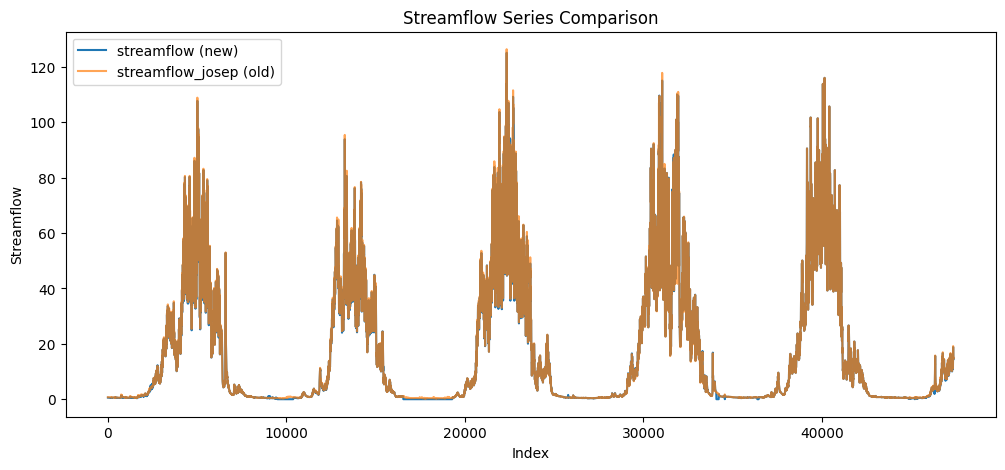

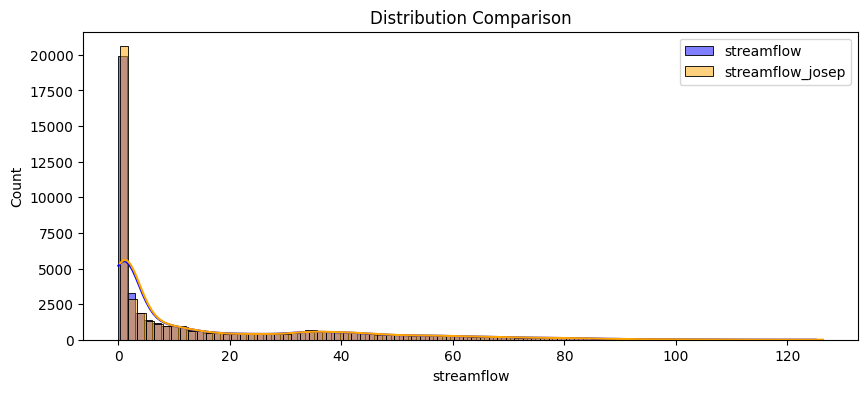

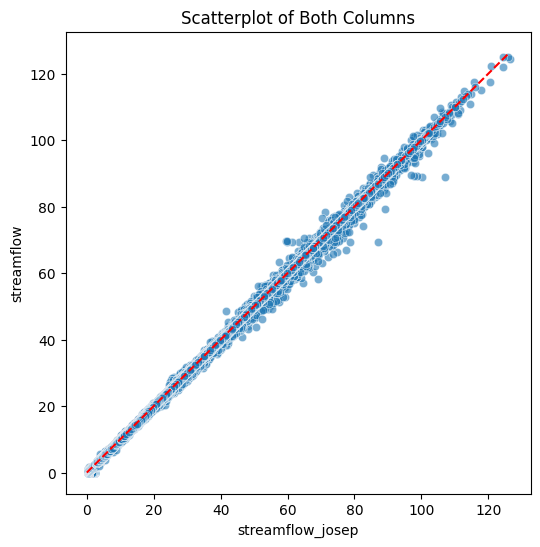


MAPE for streamflow: 4.5920%
MAPE for streamflow_josep: 5.0000%

Rows with >100% relative difference:


,date,streamflow,streamflow_josep,streamflow_hindcast,null_values,bruchji_prec,blatten_prec,blatten_temp,blatten_ray,blatten_pres_vap,...,fc_bruchji_prec_6h,fc_blatten_temp_6h,fc_blatten_prec_6h,fc_eggishorn_temp_6h,fc_eggishorn_degreeday,is_snow_melting,fc_is_snow_melting,diff,rel_diff_%,abs_pct_error
8991,2021-01-11 15:00,1.101485,0.470169,1.101485,0,0.0,0.0,-5.0,303.0,1.7,...,0.001367,-1.260393,0.000000,-59.594827,0.0,0,0,0.631317,134.274444,134.274444
9057,2021-01-14 09:00,1.113953,0.462289,1.113953,0,0.8,0.0,1.0,12.0,5.4,...,0.000391,-18.158770,0.000000,-61.458532,0.0,0,0,0.651664,140.964629,140.964629
9093,2021-01-15 21:00,0.920133,0.450638,0.920133,0,0.0,0.0,-8.8,6.0,2.9,...,9.694532,-18.687529,12.371484,-72.950989,0.0,0,0,0.469495,104.184612,104.184612
10379,2021-03-10 11:00,-0.007977,0.610000,-0.007977,0,0.0,0.0,-5.1,133.0,2.4,...,0.962305,11.650984,0.653613,-33.891780,0.0,0,0,-0.617977,-101.307664,101.307664
25779,2022-12-12 03:00,1.243065,0.612195,1.243065,0,0.0,0.0,-14.7,6.0,1.6,...,0.000000,-25.226366,0.000000,-70.815478,0.0,0,0,0.630870,103.050499,103.050499
25780,2022-12-12 04:00,1.374396,0.612195,1.374396,0,0.0,0.0,-13.8,7.0,1.8,...,0.000000,-26.115221,0.000000,-73.148315,0.0,0,0,0.762201,124.502972,124.502972
25781,2022-12-12 05:00,1.482908,0.612195,1.482908,0,0.0,0.0,-13.2,7.0,1.8,...,0.000000,-27.336260,0.000000,-75.804015,0.0,0,0,0.870713,142.228076,142.228076
25782,2022-12-12 06:00,1.541487,0.612195,1.541487,0,0.0,0.0,-12.6,7.0,1.9,...,0.000000,-28.636003,0.000000,-78.281397,0.0,0,0,0.929291,151.796596,151.796596
25783,2022-12-12 07:00,1.452962,0.612195,1.452962,0,0.0,0.0,-12.1,6.0,2.0,...,0.000000,-29.896349,0.000000,-80.267897,0.0,0,0,0.840766,137.336338,137.336338


In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load your dataset ---
# Replace with your file path
df = pd.read_csv(csv_path)

# --- 3. Basic Inspection ---
# Display basic info
print("Data Overview:")
print(df.info())
print("\nFirst rows:")
print(df.head())

# --- 4. Basic Statistics Comparison ---
cols = ["streamflow", "streamflow_josep"]

print("\nDescriptive Statistics Comparison:")
display(df[cols].describe().T)

# Additional statistics
extra_stats = pd.DataFrame({
    "mean": df[cols].mean(),
    "std": df[cols].std(),
    "median": df[cols].median(),
    "min": df[cols].min(),
    "max": df[cols].max(),
    "skew": df[cols].skew(),
    "kurtosis": df[cols].kurtosis(),
    "zeros": (df[cols] == 0).sum(),
    "negatives": (df[cols] < 0).sum(),
})
display(extra_stats)

# --- 5. Correlation & Differences ---
corr = df["streamflow"].corr(df["streamflow_josep"])
print(f"\nPearson correlation: {corr:.5f}")

df["diff"] = df["streamflow"] - df["streamflow_josep"]
df["rel_diff_%"] = 100 * df["diff"] / (df["streamflow_josep"] + 1e-9)

print("\nDifference Summary:")
display(df[["diff", "rel_diff_%"]].describe())

# --- 6. Visual Comparison ---
plt.figure(figsize=(12,5))
plt.plot(df["streamflow"], label="streamflow (new)")
plt.plot(df["streamflow_josep"], label="streamflow_josep (old)", alpha=0.7)
plt.legend()
plt.title("Streamflow Series Comparison")
plt.xlabel("Index")
plt.ylabel("Streamflow")
plt.show()

# Histogram
plt.figure(figsize=(10,4))
sns.histplot(df["streamflow"], color='blue', label='streamflow', kde=True)
sns.histplot(df["streamflow_josep"], color='orange', label='streamflow_josep', kde=True)
plt.legend()
plt.title("Distribution Comparison")
plt.show()

# Scatterplot
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["streamflow_josep"], y=df["streamflow"], alpha=0.6)
plt.xlabel("streamflow_josep")
plt.ylabel("streamflow")
plt.title("Scatterplot of Both Columns")
plt.plot([df[cols].min().min(), df[cols].max().max()],
         [df[cols].min().min(), df[cols].max().max()], 'r--')
plt.show()

# --- 7. Custom MAPE Functions ---

def mape(y_true, y_pred):
    """Standard MAPE (may explode near zeros)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def safe_mape(y_true, y_pred, eps=1e-6):
    """Robust MAPE avoiding division by zero."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

# --- 8. Compute MAPE for Each Column ---
# Example: assume we have prediction arrays for both columns
# Replace these with your actual model predictions
pred_streamflow = df["streamflow"] * 0.95  # fake prediction
pred_streamflow_josep = df["streamflow_josep"] * 0.95  # fake prediction

mape_streamflow = safe_mape(df["streamflow"], pred_streamflow)
mape_streamflow_josep = safe_mape(df["streamflow_josep"], pred_streamflow_josep)

print(f"\nMAPE for streamflow: {mape_streamflow:.4f}%")
print(f"MAPE for streamflow_josep: {mape_streamflow_josep:.4f}%")

# --- 9. Optional: Identify Where MAPE Explodes ---
df["abs_pct_error"] = np.abs((df["streamflow"] - df["streamflow_josep"]) / (df["streamflow_josep"] + 1e-9)) * 100
outliers = df[df["abs_pct_error"] > 100]
print("\nRows with >100% relative difference:")
display(outliers.head(10))
